In [1]:
#  kernel restart yaptım geri yükleme içim:
import os, random
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# -------- CONFIG --------
CONFIG = {
    "seed": 42,
    "test_size": 0.20,
    "label_col": "label",
    "url_col": "url",
    "output_dir": "outputs",
}

DATA_PATH = "~/Bitirme_Projesi_Dataset_Olusturma/Makale/final_lexical_dns_whois_cleaned.csv"

# -------- Seeds --------
def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seeds(CONFIG["seed"])

# -------- Paths --------
BASE_OUT = Path(CONFIG["output_dir"])
SHARED = BASE_OUT / "_shared"

# -------- Load dataset --------
df = pd.read_csv(DATA_PATH)
label_col = CONFIG["label_col"]
url_col = CONFIG["url_col"]

feature_cols = [c for c in df.columns if c not in [label_col, url_col]]
X = df[feature_cols].copy()
y = df[label_col].copy()

# -------- Load split indices --------
train_idx = pd.read_csv(SHARED / "split_indices_train.csv")["train_idx"].values
test_idx  = pd.read_csv(SHARED / "split_indices_test.csv")["test_idx"].values

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

# -------- Preprocessors --------
tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

linear_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# -------- Models (baseline Aşama 3 ile aynı) --------
base_models = {
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=-1, random_state=CONFIG["seed"]),
    "DecisionTree": DecisionTreeClassifier(random_state=CONFIG["seed"]),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=CONFIG["seed"], n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=CONFIG["seed"], eval_metric="logloss", n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=800, learning_rate=0.05, num_leaves=63,
        random_state=CONFIG["seed"], n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=800, learning_rate=0.05, depth=8,
        random_seed=CONFIG["seed"], verbose=False
    )
}

LINEAR_DISTANCE = {"LogReg", "KNN"}

# -------- Fit pipelines --------
pipelines = {}
for name, clf in base_models.items():
    print("Fitting:", name)
    pre = linear_preprocessor if name in LINEAR_DISTANCE else tree_preprocessor
    pipe = Pipeline([("preprocess", pre), ("model", clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

print("\n✅ Kernel reset sonrası SHAP için her şey hazır")
print("X_train:", X_train.shape, "X_test:", X_test.shape, "features:", len(feature_cols))


Fitting: LogReg
Fitting: DecisionTree
Fitting: KNN
Fitting: RandomForest
Fitting: XGBoost
Fitting: LightGBM
[LightGBM] [Info] Number of positive: 192677, number of negative: 271259
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6057
[LightGBM] [Info] Number of data points in the train set: 463936, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.415309 -> initscore=-0.342059
[LightGBM] [Info] Start training from score -0.342059
Fitting: CatBoost

✅ Kernel reset sonrası SHAP için her şey hazır
X_train: (463936, 75) X_test: (115984, 75) features: 75


In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path(r"C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale").resolve()
DATASET_PATH = PROJECT_ROOT / "final_lexical_dns_whois_cleaned.csv"

print("CWD:", os.getcwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH:", DATASET_PATH)
print("DATASET exists?", DATASET_PATH.exists())



CWD: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale
PROJECT_ROOT: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale
DATASET_PATH: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\final_lexical_dns_whois_cleaned.csv
DATASET exists? True


In [3]:
import pandas as pd

# sadece kolonları almak için
cols = pd.read_csv(DATASET_PATH, nrows=0).columns.tolist()
print("Columns count:", len(cols))
print("First 10 columns:", cols[:10])
print("Last 10 columns:", cols[-10:])

# label sayımı için sadece label kolonunu oku (hızlı)
label_col = "label" if "label" in cols else None
url_col = "url" if "url" in cols else None

print("\nGuesses -> url:", url_col, "| label:", label_col)

if label_col:
    y = pd.read_csv(DATASET_PATH, usecols=[label_col])[label_col]
    print("\nLabel value counts:")
    print(y.value_counts(dropna=False))

exclude = set([c for c in [url_col, label_col] if c])
feature_cols = [c for c in cols if c not in exclude]
print("\nFeature columns:", len(feature_cols))
print("Feature sample (first 25):", feature_cols[:25])

Columns count: 77
First 10 columns: ['url', 'label', 'url_length', 'domain_length', 'hostname_length', 'path_length', 'first_dir_length', 'tld_length', 'tld_length_domain', 'url_depth']
Last 10 columns: ['whois_success', 'domain_age_days', 'expiration_days', 'creation_year', 'domain_is_recent', 'domain_registered_before_2020', 'registrar_valid', 'name_servers_count', 'is_privacy_protected', 'whois_missing']

Guesses -> url: url | label: label

Label value counts:
label
0    339074
1    240846
Name: count, dtype: int64

Feature columns: 75
Feature sample (first 25): ['url_length', 'domain_length', 'hostname_length', 'path_length', 'first_dir_length', 'tld_length', 'tld_length_domain', 'url_depth', 'query_length', 'path_segments_count', 'num_digits', 'num_letters', 'num_special_chars', 'num_dots', 'num_hyphens', 'num_at', 'num_percent', 'num_equals', 'num_question', 'num_ampersand', 'num_hash', 'num_underscore', 'num_special', 'num_slash', 'num_params']


In [4]:
# ========= [CELL 3] Train/Test split bilgisini kontrol (varsa kayıtlı dosya var mı?) =========
# Eğer daha önce split'i dosyaya yazdıysan (json/csv/npy), burada görünsün diye
import os

candidate_files = []
for ext in ["json", "csv", "pkl", "joblib", "npy", "npz"]:
    candidate_files += list(PROJECT_ROOT.rglob(f"*split*.{ext}"))

print("Found split-related files:", len(candidate_files))
for p in candidate_files[:50]:
    print("-", p.relative_to(PROJECT_ROOT))
if len(candidate_files) > 50:
    print("... (more)")

Found split-related files: 2
- outputs\_shared\split_indices_test.csv
- outputs\_shared\split_indices_train.csv


In [5]:
# ========= [CELL 4] outputs altında model dosyalarını ve formatlarını bul =========
# Model dosyaları genelde: *.pkl, *.joblib, *.cbm, *.json, *.bst, *.bin gibi olur
model_exts = ["pkl", "joblib", "cbm", "json", "bst", "bin", "model"]
model_candidates = []
for ext in model_exts:
    model_candidates += list(PROJECT_ROOT.rglob(f"*.{ext}"))

# Biraz filtre: model/outputs isimleri geçenleri öne alalım
def score_path(p: Path) -> int:
    s = str(p).lower()
    score = 0
    for kw in ["outputs", "model", "trained", "pipeline"]:
        if kw in s:
            score += 1
    return score

model_candidates = sorted(set(model_candidates), key=lambda p: (-score_path(p), str(p)))

print("Total model-like files found:", len(model_candidates))
for p in model_candidates[:80]:
    print("-", p.relative_to(PROJECT_ROOT))
if len(model_candidates) > 80:
    print("... (more)")

Total model-like files found: 6
- outputs\DecisionTree\cache_v1\cache_meta.json
- outputs\LogReg\cache_v1\cache_meta.json
- outputs\_shared\dataset_profile.json
- outputs\_shared\duplicate_report.json
- outputs\_shared\run_info.json
- catboost_info\catboost_training.json


In [6]:
# ========= [CELL 5] outputs klasör ağacını (kısa) yazdır =========
# Maxdepth benzeri: sadece 4 seviyeye kadar gösterir
def list_tree(root: Path, max_depth: int = 4, limit: int = 400):
    root = root.resolve()
    lines = []
    for p in sorted(root.rglob("*")):
        try:
            rel = p.relative_to(root)
        except ValueError:
            continue
        depth = len(rel.parts)
        if depth <= max_depth and p.is_file():
            lines.append(str(rel))
        if len(lines) >= limit:
            lines.append("... (limit reached)")
            break
    return lines

outputs_dir = PROJECT_ROOT / "outputs"
print("outputs exists?", outputs_dir.exists())
if outputs_dir.exists():
    tree_lines = list_tree(outputs_dir, max_depth=5, limit=500)
    print("\n".join(tree_lines))

outputs exists? True
_shared\.ipynb_checkpoints\class_distribution-checkpoint.png
_shared\.ipynb_checkpoints\ensemble_shap_top20-checkpoint.png
_shared\.ipynb_checkpoints\lime_local_explanations_long-checkpoint.csv
_shared\.ipynb_checkpoints\local_samples-checkpoint.csv
_shared\.ipynb_checkpoints\metrics_table-checkpoint.csv
_shared\.ipynb_checkpoints\shap_model_comparison_full-checkpoint.csv
_shared\.ipynb_checkpoints\shap_vs_permutation_correlation-checkpoint.csv
_shared\.ipynb_checkpoints\shap_vs_permutation_top_agreement-checkpoint.csv
_shared\.ipynb_checkpoints\top20_features_stats-checkpoint.png
_shared\class_distribution.png
_shared\dataset_profile.json
_shared\duplicate_report.json
_shared\ensemble_shap_top20.png
_shared\feature_distributions\box\.ipynb_checkpoints\contains_cloud-checkpoint.png
_shared\feature_distributions\box\.ipynb_checkpoints\hostname_length-checkpoint.png
_shared\feature_distributions\box\.ipynb_checkpoints\num_hash-checkpoint.png
_shared\feature_distribut

In [7]:
# ========= [CELL 6] SHAP/PERM dosyalarının kolon isimlerini kontrol et (kolon uyuşmazlığı için) =========
import pandas as pd

# perm_importance.csv ve shap_importance.csv örneklerini bul
perm_files = list(PROJECT_ROOT.rglob("perm_importance*.csv")) + list(PROJECT_ROOT.rglob("*perm*importance*.csv"))
shap_files = list(PROJECT_ROOT.rglob("shap_importance*.csv")) + list(PROJECT_ROOT.rglob("*shap*importance*.csv"))

print("perm files:", len(perm_files))
print("shap files:", len(shap_files))

def peek_csv_cols(path: Path, nrows=5):
    try:
        tmp = pd.read_csv(path, nrows=nrows)
        return tmp.columns.tolist()
    except Exception as e:
        return [f"ERROR: {e}"]

print("\n--- PERM samples (first 10) ---")
for p in perm_files[:10]:
    print(p.relative_to(PROJECT_ROOT), "->", peek_csv_cols(p))

print("\n--- SHAP samples (first 10) ---")
for p in shap_files[:10]:
    print(p.relative_to(PROJECT_ROOT), "->", peek_csv_cols(p))

perm files: 22
shap files: 42

--- PERM samples (first 10) ---
outputs\CatBoost\global\perm_importance.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\DecisionTree\global\perm_importance.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\DecisionTree\global\.ipynb_checkpoints\perm_importance-checkpoint.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\KNN\global\perm_importance.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\KNN\global\.ipynb_checkpoints\perm_importance-checkpoint.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\LightGBM\global\perm_importance.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\LogReg\global\perm_importance.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\LogReg\global\.ipynb_checkpoints\perm_importance-checkpoint.csv -> ['feature', 'importance_mean', 'importance_std']
outputs\RandomForest\global\perm_importance.csv -> ['feature', 'importance_mean', 'im

In [8]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

SEED = 42
N_EXPLAIN = 10_000          # explain sample (stratified)
BG_SIZE = 200               # background size (özellikle XGB fallback için)
CHUNK = 1000                # shap hesap chunk boyutu
CACHE_DIRNAME = "cache_v1"  # outputs/{Model}/cache_v1/

PROJECT_ROOT = Path(r"C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale").resolve()
DATASET_PATH = PROJECT_ROOT / "final_lexical_dns_whois_cleaned.csv"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SHARED_DIR = OUTPUTS_DIR / "_shared"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH exists?", DATASET_PATH.exists())
print("OUTPUTS_DIR exists?", OUTPUTS_DIR.exists())
print("SHARED_DIR exists?", SHARED_DIR.exists())

PROJECT_ROOT: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale
DATASET_PATH exists? True
OUTPUTS_DIR exists? True
SHARED_DIR exists? True


In [9]:
# Split index dosyaları sende var:
test_idx_path = SHARED_DIR / "split_indices_test.csv"
train_idx_path = SHARED_DIR / "split_indices_train.csv"
assert test_idx_path.exists(), f"Missing: {test_idx_path}"
assert train_idx_path.exists(), f"Missing: {train_idx_path}"

test_idx = pd.read_csv(test_idx_path).iloc[:,0].to_numpy()
train_idx = pd.read_csv(train_idx_path).iloc[:,0].to_numpy()

# Sadece header al
cols = pd.read_csv(DATASET_PATH, nrows=0).columns.tolist()
assert "url" in cols and "label" in cols, "url/label kolonları bulunamadı"

feature_cols = [c for c in cols if c not in ("url", "label")]
print("Total features:", len(feature_cols))

# Test set için sadece gerekli kolonları oku:
usecols = ["label"] + feature_cols
df_test = pd.read_csv(DATASET_PATH, usecols=usecols).iloc[test_idx].reset_index(drop=True)

X_test = df_test[feature_cols]
y_test = df_test["label"].astype(int)

print("Test shape:", X_test.shape, "Label dist:", y_test.value_counts().to_dict())

Total features: 75
Test shape: (115984, 75) Label dist: {0: 67815, 1: 48169}


In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=min(N_EXPLAIN, len(X_test)), random_state=SEED)
idx_explain, _ = next(sss.split(X_test, y_test))
X_explain = X_test.iloc[idx_explain].copy().reset_index(drop=True)
y_explain = y_test.iloc[idx_explain].copy().reset_index(drop=True)

# background: explain set içinden küçük bir örnek
bg_n = min(BG_SIZE, len(X_explain))
bg_idx = np.random.RandomState(SEED).choice(len(X_explain), size=bg_n, replace=False)
X_bg = X_explain.iloc[bg_idx].copy().reset_index(drop=True)

print("Explain shape:", X_explain.shape, "BG shape:", X_bg.shape)
print("Explain label dist:", y_explain.value_counts().to_dict())

Explain shape: (10000, 75) BG shape: (200, 75)
Explain label dist: {0: 5847, 1: 4153}


In [11]:
def find_model_files(outputs_dir: Path):
    exts = (".pkl", ".joblib", ".cbm", ".json", ".bst", ".bin")
    hits = []
    for p in outputs_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts and ("model" in p.name.lower() or "pipeline" in p.name.lower()):
            hits.append(p)
    return sorted(hits, key=lambda x: str(x).lower())

hits = find_model_files(OUTPUTS_DIR)
print("Model file hits:", len(hits))
for h in hits[:50]:
    print("-", h.relative_to(PROJECT_ROOT))
if len(hits) > 50:
    print("... (more)")

Model file hits: 0


In [12]:
# ========= 1) Diskten yükleme (bulursak) =========
def try_load_joblib(path: Path):
    try:
        return joblib.load(path)
    except Exception:
        return None

# Burada otomatik yükleme yoksa MODELS'i manuel dolduracağız.
MODELS = {}

# ========= 2) MANUEL: Notebook RAM'indeki modelleri buraya koy =========
# Aşağıdaki isimler ÖRNEK. Sende değişken adları farklıysa değiştir.
# Örn: logreg_model, dt_model, rf_model, lgbm_model, cat_model, xgb_model gibi.

# MODELS = {
#     "LogReg": logreg_model,
#     "DecisionTree": dt_model,
#     "RandomForest": rf_model,
#     "LightGBM": lgbm_model,
#     "CatBoost": cat_model,
#     "XGBoost": xgb_model
# }

print("MODELS keys:", list(MODELS.keys()))
print("If empty, you must fill MODELS mapping with your trained model objects.")

MODELS keys: []
If empty, you must fill MODELS mapping with your trained model objects.


In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
import json
import time
import shap

# =========================
# CACHE AYARLARI
# =========================
SEED        = CONFIG["seed"] if "CONFIG" in globals() and "seed" in CONFIG else 42
N_EXPLAIN   = 10_000       # cache sample size
BG_N        = 300          # XGBoost fallback background size
CHUNK_SIZE  = 2000         # shap chunk
CACHE_TAG   = "cache_v1"   # outputs/{Model}/cache_v1/

MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]  # KNN yok
TREE_MODELS = {"DecisionTree", "RandomForest", "LightGBM", "CatBoost"}  # XGBoost ayrı ele alacağız

rng = np.random.RandomState(SEED)

BASE_OUT = Path(BASE_OUT) if "BASE_OUT" in globals() else Path("outputs")  # sende BASE_OUT zaten vardı

# === explain sample: test setten stratified seç ===
sss = StratifiedShuffleSplit(n_splits=1, train_size=min(N_EXPLAIN, len(X_test)), random_state=SEED)
idx_explain, _ = next(sss.split(X_test, y_test))

X_explain_raw = X_test.iloc[idx_explain].copy().reset_index(drop=True)
y_explain     = y_test.iloc[idx_explain].astype(int).copy().reset_index(drop=True)

print("✅ Explain sample:", X_explain_raw.shape, "Label dist:", y_explain.value_counts().to_dict())

✅ Explain sample: (10000, 75) Label dist: {0: 5847, 1: 4153}


In [14]:
def to_2d_shap(shap_vals):
    if isinstance(shap_vals, list):
        if len(shap_vals) >= 2:
            return np.asarray(shap_vals[1])  # class=1
        return np.asarray(shap_vals[-1])
    arr = np.asarray(shap_vals)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        if arr.shape[-1] >= 2:
            return arr[:, :, 1]
        return np.squeeze(arr, axis=-1)
    return np.squeeze(arr)

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def save_cache_bundle(out_dir: Path, X_explain_df: pd.DataFrame, y_explain: pd.Series, shap_mat: np.ndarray, meta: dict):
    ensure_dir(out_dir)

    X_path    = out_dir / "explain_X.csv"
    y_path    = out_dir / "explain_y.csv"
    sv_path   = out_dir / "shap_values.npz"
    meta_path = out_dir / "cache_meta.json"

    # CSV kaydet
    X_explain_df.to_csv(X_path, index=False, encoding="utf-8")
    y_explain.to_frame("label").to_csv(y_path, index=False, encoding="utf-8")

    # SHAP matrisini sıkıştırılmış kaydet
    np.savez_compressed(sv_path, shap_values=shap_mat)

    # meta
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    print(f"💾 Cache saved -> {out_dir}")

In [20]:
import time, json
import numpy as np
import pandas as pd
from pathlib import Path
import shap
from sklearn.model_selection import StratifiedShuffleSplit

# =========================
# AYARLAR
# =========================
SEED       = CONFIG["seed"] if "CONFIG" in globals() and "seed" in CONFIG else 42
N_EXPLAIN  = 10_000      # cache sample size
BG_N       = 300         # background size (RF/XGB fallback)
CHUNK_SIZE = 2000        # chunk size
CACHE_TAG  = "cache_v1"  # outputs/{Model}/cache_v1/

MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]  # ✅ KNN yok
TREE_MODELS = {"DecisionTree", "RandomForest", "LightGBM", "CatBoost"}                 # XGB ayrı ele alınacak

rng = np.random.RandomState(SEED)

# BASE_OUT sende muhtemelen zaten var; yoksa outputs kullan
BASE_OUT = Path(BASE_OUT) if "BASE_OUT" in globals() else Path("outputs")
BASE_OUT.mkdir(parents=True, exist_ok=True)

# =========================
# Yardımcı Fonksiyonlar
# =========================
def to_2d_shap(shap_vals):
    if isinstance(shap_vals, list):
        if len(shap_vals) >= 2:
            return np.asarray(shap_vals[1])  # class=1
        return np.asarray(shap_vals[-1])
    arr = np.asarray(shap_vals)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        if arr.shape[-1] >= 2:
            return arr[:, :, 1]
        return np.squeeze(arr, axis=-1)
    return np.squeeze(arr)

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def save_cache_bundle(out_dir: Path, X_explain_df: pd.DataFrame, y_explain: pd.Series, shap_mat: np.ndarray, meta: dict):
    ensure_dir(out_dir)

    X_path     = out_dir / "explain_X.csv"
    y_path     = out_dir / "explain_y.csv"
    sv_path    = out_dir / "shap_values.npz"
    meta_path  = out_dir / "cache_meta.json"

    X_explain_df.to_csv(X_path, index=False, encoding="utf-8")
    y_explain.to_frame("label").to_csv(y_path, index=False, encoding="utf-8")
    np.savez_compressed(sv_path, shap_values=shap_mat)

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    print(f"💾 Cache saved -> {out_dir}", flush=True)

# =========================
# Explain Sample (Stratified) seç
# =========================
assert "X_test" in globals() and "y_test" in globals(), "X_test / y_test notebook'ta yok"
assert "X_train" in globals(), "X_train notebook'ta yok"
assert "feature_cols" in globals(), "feature_cols notebook'ta yok"
assert "pipelines" in globals(), "pipelines dict notebook'ta yok"

sss = StratifiedShuffleSplit(n_splits=1, train_size=min(N_EXPLAIN, len(X_test)), random_state=SEED)
idx_explain, _ = next(sss.split(X_test, y_test))

X_explain_raw = X_test.iloc[idx_explain].copy().reset_index(drop=True)
y_explain     = y_test.iloc[idx_explain].astype(int).copy().reset_index(drop=True)

print(f"✅ Explain sample hazır: {X_explain_raw.shape} | label dist={y_explain.value_counts().to_dict()}", flush=True)

# =========================
# CACHE ÜRET
# =========================
print(f"\n🚀 SHAP CACHE START (n_explain={len(X_explain_raw)}, seed={SEED})", flush=True)

for name in MODELS:
    t0 = time.time()
    print("\n============================", flush=True)
    print("Model:", name, flush=True)
    print("============================", flush=True)

    pipe = pipelines[name]
    model = pipe.named_steps["model"]
    preprocess = pipe.named_steps["preprocess"]

    out_dir = ensure_dir(BASE_OUT / name / CACHE_TAG)

    # zaten varsa atla
    if (out_dir / "shap_values.npz").exists() and (out_dir / "cache_meta.json").exists():
        print("⏩ Cache zaten var, atlandı:", name, flush=True)
        continue

    # 1) preprocess
    print("1) preprocess.transform(X_explain_raw) ...", flush=True)
    X_exp_proc = preprocess.transform(X_explain_raw)
    print("   ✅ X_exp_proc shape:", getattr(X_exp_proc, "shape", None), flush=True)

    # 2) SHAP hesap
    # -------------------------
    # XGBoost özel-case
    # -------------------------
    if name == "XGBoost":
        print("2) XGBoost -> shap.Explainer(f, bg) (model-agnostic) kullanılacak", flush=True)

        Xtr_proc = preprocess.transform(X_train)
        bg_n = min(BG_N, Xtr_proc.shape[0])
        idx_bg = rng.choice(Xtr_proc.shape[0], size=bg_n, replace=False)
        bg = Xtr_proc[idx_bg]

        f = lambda x: model.predict_proba(x)[:, 1]
        explainer = shap.Explainer(f, bg)

        n = X_exp_proc.shape[0]
        shap_chunks = []
        num_chunks = (n + CHUNK_SIZE - 1) // CHUNK_SIZE
        print(f"3) Chunked shap (XGB-Explainer): chunks={num_chunks}", flush=True)

        for i in range(num_chunks):
            a = i * CHUNK_SIZE
            b = min((i + 1) * CHUNK_SIZE, n)
            print(f"   ▶ chunk {i+1}/{num_chunks} rows {a}:{b}", flush=True)
            shap_exp = explainer(X_exp_proc[a:b])
            shap_chunks.append(shap_exp.values)

        shap_mat = np.vstack(shap_chunks)

        meta = {
            "model": name,
            "method": "shap.Explainer(f, bg) on explain_sample",
            "seed": int(SEED),
            "n_explain": int(n),
            "chunk_size": int(CHUNK_SIZE),
            "bg_n": int(bg_n),
            "note": "XGBoost TreeExplainer base_score issue -> used model-agnostic Explainer.",
        }

    # -------------------------
    # TREE MODELLER
    # -------------------------
    elif name in TREE_MODELS:

        # RandomForest özel-case (hız için)
        if name == "RandomForest":
            print("2) RandomForest -> shap.Explainer fallback (hızlı mod)", flush=True)

            Xtr_proc = preprocess.transform(X_train)
            bg_n = min(BG_N, Xtr_proc.shape[0])
            idx_bg = rng.choice(Xtr_proc.shape[0], size=bg_n, replace=False)
            bg = Xtr_proc[idx_bg]

            f = lambda x: model.predict_proba(x)[:, 1]
            explainer = shap.Explainer(f, bg)

            n = X_exp_proc.shape[0]
            shap_chunks = []
            num_chunks = (n + CHUNK_SIZE - 1) // CHUNK_SIZE
            print(f"3) Chunked shap (RF-Explainer): chunks={num_chunks}", flush=True)

            for i in range(num_chunks):
                a = i * CHUNK_SIZE
                b = min((i + 1) * CHUNK_SIZE, n)
                print(f"   ▶ chunk {i+1}/{num_chunks} rows {a}:{b}", flush=True)
                shap_exp = explainer(X_exp_proc[a:b])
                shap_chunks.append(shap_exp.values)

            shap_mat = np.vstack(shap_chunks)

            meta = {
                "model": name,
                "method": "shap.Explainer(f, bg) (RF fallback)",
                "seed": int(SEED),
                "n_explain": int(n),
                "chunk_size": int(CHUNK_SIZE),
                "bg_n": int(bg_n),
                "note": "RF TreeExplainer was too slow -> used model-agnostic Explainer.",
            }

        else:
            print("2) TreeExplainer hazırlanıyor...", flush=True)

            try:
                explainer = shap.TreeExplainer(model)
            except Exception as e:
                print("   ⚠️ TreeExplainer başarısız -> data fallback:", str(e)[:120], "...", flush=True)
                explainer = shap.TreeExplainer(model, X_exp_proc[:2000])

            _ = explainer.shap_values(X_exp_proc[:50], check_additivity=False)

            n = X_exp_proc.shape[0]
            shap_chunks = []
            num_chunks = (n + CHUNK_SIZE - 1) // CHUNK_SIZE
            print(f"3) Chunked shap (Tree): chunks={num_chunks}", flush=True)

            for i in range(num_chunks):
                a = i * CHUNK_SIZE
                b = min((i + 1) * CHUNK_SIZE, n)
                print(f"   ▶ chunk {i+1}/{num_chunks} rows {a}:{b}", flush=True)
                shap_vals = explainer.shap_values(X_exp_proc[a:b], check_additivity=False)
                shap_chunks.append(to_2d_shap(shap_vals))

            shap_mat = np.vstack(shap_chunks)

            meta = {
                "model": name,
                "method": "TreeExplainer on explain_sample",
                "seed": int(SEED),
                "n_explain": int(n),
                "chunk_size": int(CHUNK_SIZE),
                "check_additivity": False,
            }

    # -------------------------
    # LOGISTIC REGRESSION
    # -------------------------
    else:
        print("2) LinearExplainer hazırlanıyor...", flush=True)

        Xtr_proc = preprocess.transform(X_train)
        bg_n = min(20_000, Xtr_proc.shape[0])
        idx_bg = rng.choice(Xtr_proc.shape[0], size=bg_n, replace=False)
        bg = Xtr_proc[idx_bg]

        explainer = shap.LinearExplainer(model, bg)

        print("3) shap_values (Linear) ...", flush=True)
        shap_vals = explainer.shap_values(X_exp_proc)
        shap_mat = to_2d_shap(shap_vals)

        meta = {
            "model": name,
            "method": "LinearExplainer on explain_sample",
            "seed": int(SEED),
            "n_explain": int(X_exp_proc.shape[0]),
            "bg_n": int(bg_n),
        }

    # 3) Kaydet (RAW X + shap_mat)
    meta["feature_cols"] = feature_cols
    meta["label_col"] = "label"
    meta["n_features"] = int(len(feature_cols))

    save_cache_bundle(out_dir, X_explain_raw[feature_cols], y_explain, shap_mat, meta)
    print(f"✅ {name} cache bitti. Süre: {(time.time()-t0)/60:.1f} dk", flush=True)

print("\n🎉 DONE: 6 model için cache üretildi.", flush=True)

✅ Explain sample hazır: (10000, 75) | label dist={0: 5847, 1: 4153}

🚀 SHAP CACHE START (n_explain=10000, seed=42)

Model: LogReg
⏩ Cache zaten var, atlandı: LogReg

Model: DecisionTree
⏩ Cache zaten var, atlandı: DecisionTree

Model: RandomForest
1) preprocess.transform(X_explain_raw) ...
   ✅ X_exp_proc shape: (10000, 75)
2) RandomForest -> shap.Explainer fallback (hızlı mod)
3) Chunked shap (RF-Explainer): chunks=5
   ▶ chunk 1/5 rows 0:2000


PermutationExplainer explainer: 2001it [21:26,  1.55it/s]                                                              

   ▶ chunk 2/5 rows 2000:4000



PermutationExplainer explainer: 2001it [21:46,  1.52it/s]                                                              

   ▶ chunk 3/5 rows 4000:6000


...

   ▶ chunk 5/5 rows 8000:10000


PermutationExplainer explainer: 2001it [04:20,  7.36it/s]                                                              


💾 Cache saved -> outputs\XGBoost\cache_v1
✅ XGBoost cache bitti. Süre: 21.4 dk

Model: LightGBM
1) preprocess.transform(X_explain_raw) ...
   ✅ X_exp_proc shape: (10000, 75)
2) TreeExplainer hazırlanıyor...
3) Chunked shap (Tree): chunks=5
   ▶ chunk 1/5 rows 0:2000


C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


   ▶ chunk 2/5 rows 2000:4000
   ▶ chunk 3/5 rows 4000:6000
   ▶ chunk 4/5 rows 6000:8000
   ▶ chunk 5/5 rows 8000:10000
💾 Cache saved -> outputs\LightGBM\cache_v1
✅ LightGBM cache bitti. Süre: 0.9 dk

Model: CatBoost
1) preprocess.transform(X_explain_raw) ...
   ✅ X_exp_proc shape: (10000, 75)
2) TreeExplainer hazırlanıyor...
3) Chunked shap (Tree): chunks=5
   ▶ chunk 1/5 rows 0:2000
   ▶ chunk 2/5 rows 2000:4000
   ▶ chunk 3/5 rows 4000:6000
   ▶ chunk 4/5 rows 6000:8000
   ▶ chunk 5/5 rows 8000:10000
💾 Cache saved -> outputs\CatBoost\cache_v1
✅ CatBoost cache bitti. Süre: 1.2 dk

🎉 DONE: 6 model için cache üretildi.


In [21]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# AYARLAR
# =========================
MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]
CACHE_TAG = "cache_v1"

# çıktı klasörleri
BASE_OUT = Path(BASE_OUT) if "BASE_OUT" in globals() else Path("outputs")
ANALYSIS_DIRNAME = "feature_analysis_from_cache"   # outputs/{Model}/feature_analysis_from_cache/...

# grafik için örnekleme (çok yoğun olmasın)
PLOT_MAX_POINTS = 15000    # scatter için max nokta
SEED = 42
rng = np.random.RandomState(SEED)

# bins (quantile)
N_BINS = 5  # Q1-Q5

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def safe_filename(s: str) -> str:
    # windows uyumlu
    return "".join([c if c.isalnum() or c in "._-" else "_" for c in s])

def load_cache(model_name: str):
    cache_dir = BASE_OUT / model_name / CACHE_TAG
    X_path = cache_dir / "explain_X.csv"
    y_path = cache_dir / "explain_y.csv"
    sv_path = cache_dir / "shap_values.npz"
    meta_path = cache_dir / "cache_meta.json"

    assert X_path.exists(), f"Missing {X_path}"
    assert y_path.exists(), f"Missing {y_path}"
    assert sv_path.exists(), f"Missing {sv_path}"
    assert meta_path.exists(), f"Missing {meta_path}"

    X = pd.read_csv(X_path)
    y = pd.read_csv(y_path)["label"].astype(int)
    sv = np.load(sv_path)["shap_values"]  # (n, features)
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    # feature sırası kontrol
    feat_cols = meta.get("feature_cols", list(X.columns))
    X = X[feat_cols]
    return X, y, sv, meta, cache_dir

def maybe_sample_for_plot(Xcol: np.ndarray, shap_col: np.ndarray, y: np.ndarray, max_points: int):
    n = len(Xcol)
    if n <= max_points:
        return Xcol, shap_col, y
    idx = rng.choice(n, size=max_points, replace=False)
    return Xcol[idx], shap_col[idx], y[idx]

def plot_dependence(feature: str, Xcol, shap_col, out_path: Path):
    plt.figure(figsize=(8, 5))
    plt.scatter(Xcol, shap_col, s=6, alpha=0.35)
    plt.xlabel(feature)
    plt.ylabel(f"SHAP({feature})")
    plt.title(f"Dependence: {feature}")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def plot_distribution(feature: str, Xcol, y, out_path: Path):
    # benign=0 vs phishing=1 overlay histogram
    plt.figure(figsize=(8, 5))
    x0 = Xcol[y == 0]
    x1 = Xcol[y == 1]
    plt.hist(x0, bins=50, alpha=0.5, label="benign (0)")
    plt.hist(x1, bins=50, alpha=0.5, label="phishing (1)")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.title(f"Distribution: {feature} (benign vs phishing)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def risk_bins_table(feature: str, Xcol, shap_col, y, n_bins: int = 5):
    # quantile bins (Q1..Q5)
    s = pd.Series(Xcol)
    # duplicate bin edges olursa (çok tekrar eden değer) qcut hata verir -> duplicates='drop'
    bins = pd.qcut(s, q=n_bins, duplicates="drop")
    df = pd.DataFrame({
        "bin": bins.astype(str),
        "x": Xcol,
        "shap": shap_col,
        "y": y
    })

    grp = df.groupby("bin", observed=True).agg(
        n=("y", "size"),
        phishing_rate=("y", "mean"),
        mean_shap=("shap", "mean"),
        mean_abs_shap=("shap", lambda v: np.mean(np.abs(v))),
        x_min=("x", "min"),
        x_max=("x", "max"),
        x_mean=("x", "mean"),
    ).reset_index()

    # phishing_rate yüzde
    grp["phishing_rate"] = (grp["phishing_rate"] * 100.0).round(2)
    return grp.sort_values(["x_min"])

print("✅ Cache-based feature analysis starting...")

for model_name in MODELS:
    print("\n============================")
    print("Model:", model_name)
    print("============================")

    X, y, sv, meta, cache_dir = load_cache(model_name)
    features = list(X.columns)

    # output dirs
    out_base = ensure_dir(BASE_OUT / model_name / ANALYSIS_DIRNAME)
    out_dep  = ensure_dir(out_base / "dependence")
    out_dist = ensure_dir(out_base / "distribution")
    out_bins = ensure_dir(out_base / "risk_bins")

    # risk-bins tüm feature için tek dosyada birleştirelim
    all_bins_rows = []

    for j, feat in enumerate(features):
        Xcol = X[feat].to_numpy()
        shap_col = sv[:, j]
        y_np = y.to_numpy()

        # 1) risk bins table
        tb = risk_bins_table(feat, Xcol, shap_col, y_np, n_bins=N_BINS)
        tb.insert(0, "feature", feat)
        all_bins_rows.append(tb)

        # 2) dependence plot (sample)
        Xp, Sp, yp = maybe_sample_for_plot(Xcol, shap_col, y_np, PLOT_MAX_POINTS)
        dep_path = out_dep / f"{safe_filename(feat)}.png"
        plot_dependence(feat, Xp, Sp, dep_path)

        # 3) distribution plot
        dist_path = out_dist / f"{safe_filename(feat)}.png"
        plot_distribution(feat, Xcol, y_np, dist_path)

        if (j+1) % 10 == 0:
            print(f"  ... {j+1}/{len(features)} features done", flush=True)

    # tüm risk bins birleştir
    df_bins = pd.concat(all_bins_rows, ignore_index=True)
    bins_csv = out_bins / "risk_bins_all_features.csv"
    df_bins.to_csv(bins_csv, index=False, encoding="utf-8")

    print(f"✅ Saved: {out_base}")
    print(f"   - dependence/: {len(features)} png")
    print(f"   - distribution/: {len(features)} png")
    print(f"   - risk_bins_all_features.csv")

print("\n🎉 ALL DONE.")

✅ Cache-based feature analysis starting...

Model: LogReg
  ... 10/75 features done
  ... 20/75 features done
  ... 30/75 features done
  ... 40/75 features done
  ... 50/75 features done
  ... 60/75 features done
  ... 70/75 features done
✅ Saved: outputs\LogReg\feature_analysis_from_cache
   - dependence/: 75 png
   - distribution/: 75 png
   - risk_bins_all_features.csv

Model: DecisionTree
  ... 10/75 features done
  ... 20/75 features done
  ... 30/75 features done
  ... 40/75 features done
  ... 50/75 features done
  ... 60/75 features done
  ... 70/75 features done
✅ Saved: outputs\DecisionTree\feature_analysis_from_cache
   - dependence/: 75 png
   - distribution/: 75 png
   - risk_bins_all_features.csv

Model: RandomForest
  ... 10/75 features done
  ... 20/75 features done
  ... 30/75 features done
  ... 40/75 features done
  ... 50/75 features done
  ... 60/75 features done
  ... 70/75 features done
✅ Saved: outputs\RandomForest\feature_analysis_from_cache
   - dependence/: 

In [22]:
import pandas as pd
import numpy as np
from pathlib import Path

MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]

BASE_OUT = Path(BASE_OUT) if "BASE_OUT" in globals() else Path("outputs")
ANALYSIS_DIRNAME = "feature_analysis_from_cache"

def interpret_shap_direction(mean_shap):
    if mean_shap > 0:
        return "pozitif olup modelin phishing sınıfına yönelimini artırmaktadır"
    elif mean_shap < 0:
        return "negatif olup modelin benign sınıfa yönelimini artırmaktadır"
    else:
        return "nötr etkiye sahiptir"

def generate_comment(feature, row):
    x_min = row["x_min"]
    x_max = row["x_max"]
    phishing_rate = row["phishing_rate"]
    mean_shap = row["mean_shap"]

    direction_text = interpret_shap_direction(mean_shap)

    comment = (
        f"Feature '{feature}' için en yüksek risk aralığı "
        f"{x_min:.4f} – {x_max:.4f} değerleri arasındadır. "
        f"Bu aralıkta phishing oranı %{phishing_rate:.2f} olarak gözlemlenmiştir. "
        f"Aynı aralıkta ortalama SHAP değeri {mean_shap:.4f} olup, "
        f"bu değer {direction_text}. "
        f"Bu durum, ilgili feature'ın belirtilen aralıkta phishing davranışını "
        f"anlamlı şekilde etkilediğini göstermektedir."
    )

    return comment

print("🚀 TOP20 akademik yorum üretimi başlıyor...\n")

all_models_report = []

for model in MODELS:

    print("Model:", model)

    shap_path = BASE_OUT / model / "global" / "shap_importance.csv"
    risk_path = BASE_OUT / model / ANALYSIS_DIRNAME / "risk_bins" / "risk_bins_all_features.csv"

    if not shap_path.exists() or not risk_path.exists():
        print("  ⚠️ Gerekli dosyalar eksik, atlandı.\n")
        continue

    df_shap = pd.read_csv(shap_path)
    df_risk = pd.read_csv(risk_path)

    # Top20 feature
    top20 = df_shap.sort_values("mean_abs_shap", ascending=False).head(20)["feature"].tolist()

    model_report_lines = []
    model_report_lines.append(f"\n==============================")
    model_report_lines.append(f"{model} Modeli – Top20 Feature Analizi")
    model_report_lines.append(f"==============================\n")

    for feat in top20:
        df_feat = df_risk[df_risk["feature"] == feat]

        if df_feat.empty:
            continue

        # En yüksek phishing rate bin
        idx_max = df_feat["phishing_rate"].idxmax()
        best_row = df_feat.loc[idx_max]

        comment = generate_comment(feat, best_row)
        model_report_lines.append(comment)
        model_report_lines.append("")

    # Kaydet
    model_report_text = "\n".join(model_report_lines)
    out_txt = BASE_OUT / model / ANALYSIS_DIRNAME / "top20_academic_report.txt"
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write(model_report_text)

    print(f"  ✅ Kaydedildi -> {out_txt}\n")

    all_models_report.append(model_report_text)

# Tüm modeller birleşik rapor
combined_report = "\n\n".join(all_models_report)
combined_path = BASE_OUT / "ALL_MODELS_TOP20_ACADEMIC_REPORT.txt"

with open(combined_path, "w", encoding="utf-8") as f:
    f.write(combined_report)

print("🎉 Tüm modeller için akademik yorum üretildi.")
print("Birleşik rapor:", combined_path)

🚀 TOP20 akademik yorum üretimi başlıyor...

Model: LogReg
  ✅ Kaydedildi -> outputs\LogReg\feature_analysis_from_cache\top20_academic_report.txt

Model: DecisionTree
  ✅ Kaydedildi -> outputs\DecisionTree\feature_analysis_from_cache\top20_academic_report.txt

Model: RandomForest
  ✅ Kaydedildi -> outputs\RandomForest\feature_analysis_from_cache\top20_academic_report.txt

Model: XGBoost
  ✅ Kaydedildi -> outputs\XGBoost\feature_analysis_from_cache\top20_academic_report.txt

Model: LightGBM
  ✅ Kaydedildi -> outputs\LightGBM\feature_analysis_from_cache\top20_academic_report.txt

Model: CatBoost
  ✅ Kaydedildi -> outputs\CatBoost\feature_analysis_from_cache\top20_academic_report.txt

🎉 Tüm modeller için akademik yorum üretildi.
Birleşik rapor: outputs\ALL_MODELS_TOP20_ACADEMIC_REPORT.txt


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]
CACHE_TAG = "cache_v1"
ANALYSIS_DIRNAME = "feature_analysis_from_cache"

BASE_OUT = Path(BASE_OUT) if "BASE_OUT" in globals() else Path("outputs")

# Plot sample (dependence scatter yoğunluğu azaltmak için)
PLOT_MAX_POINTS = 15000
SEED = 42
rng = np.random.RandomState(SEED)

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def safe_filename(s: str) -> str:
    return "".join([c if c.isalnum() or c in "._-" else "_" for c in s])

def maybe_sample_for_plot(x: np.ndarray, s: np.ndarray, y: np.ndarray, max_points: int):
    n = len(x)
    if n <= max_points:
        return x, s, y
    idx = rng.choice(n, size=max_points, replace=False)
    return x[idx], s[idx], y[idx]

def load_cache(model_name: str):
    cache_dir = BASE_OUT / model_name / CACHE_TAG
    X_path = cache_dir / "explain_X.csv"
    y_path = cache_dir / "explain_y.csv"
    sv_path = cache_dir / "shap_values.npz"
    meta_path = cache_dir / "cache_meta.json"

    assert X_path.exists(), f"Missing {X_path}"
    assert y_path.exists(), f"Missing {y_path}"
    assert sv_path.exists(), f"Missing {sv_path}"
    assert meta_path.exists(), f"Missing {meta_path}"

    X = pd.read_csv(X_path)
    y = pd.read_csv(y_path)["label"].astype(int)
    sv = np.load(sv_path)["shap_values"]  # (n, features)
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    feat_cols = meta.get("feature_cols", list(X.columns))
    X = X[feat_cols]
    return X, y, sv, meta

def get_top20_features(model_name: str):
    shap_path = BASE_OUT / model_name / "global" / "shap_importance.csv"
    assert shap_path.exists(), f"Missing {shap_path}"
    df_shap = pd.read_csv(shap_path).sort_values("mean_abs_shap", ascending=False)
    return df_shap.head(20)["feature"].tolist(), df_shap

def load_risk_bins(model_name: str):
    risk_path = BASE_OUT / model_name / ANALYSIS_DIRNAME / "risk_bins" / "risk_bins_all_features.csv"
    assert risk_path.exists(), f"Missing {risk_path}"
    return pd.read_csv(risk_path)

def plot_risk_bins(feature: str, df_feat_bins: pd.DataFrame, out_path: Path):
    # bin sırası: x_min'e göre
    dfb = df_feat_bins.sort_values("x_min").copy()

    labels = [f"Q{i+1}\n[{r.x_min:.2f},{r.x_max:.2f}]" for i, r in enumerate(dfb.itertuples())]
    phishing = dfb["phishing_rate"].to_numpy()  # percent already
    mean_shap = dfb["mean_shap"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(range(len(labels)), phishing)
    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels, rotation=0)
    ax1.set_ylabel("Phishing rate (%)")
    ax1.set_title(f"Risk bins (Q1–Q5): {feature}")

    ax2 = ax1.twinx()
    ax2.plot(range(len(labels)), mean_shap, marker="o")
    ax2.set_ylabel("Mean SHAP (signed)")

    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

def plot_dependence(feature: str, x: np.ndarray, s: np.ndarray, out_path: Path):
    fig = plt.figure(figsize=(8, 5))
    plt.scatter(x, s, s=6, alpha=0.35)
    plt.xlabel(feature)
    plt.ylabel(f"SHAP({feature})")
    plt.title(f"Dependence: {feature}")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

def plot_distribution(feature: str, x: np.ndarray, y: np.ndarray, out_path: Path):
    x0 = x[y == 0]
    x1 = x[y == 1]
    fig = plt.figure(figsize=(8, 5))
    plt.hist(x0, bins=50, alpha=0.5, label="benign (0)")
    plt.hist(x1, bins=50, alpha=0.5, label="phishing (1)")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.title(f"Distribution: {feature} (benign vs phishing)")
    plt.legend()
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

def plot_top20_summary(model_name: str, top20: list, df_risk: pd.DataFrame, out_path: Path):
    # Her feature için en yüksek phishing_rate bin değerini al
    rows = []
    for feat in top20:
        df_feat = df_risk[df_risk["feature"] == feat]
        if df_feat.empty:
            continue
        best = df_feat.loc[df_feat["phishing_rate"].idxmax()]
        rows.append((feat, float(best["phishing_rate"]), float(best["mean_shap"]), float(best["x_min"]), float(best["x_max"])))

    if not rows:
        return

    df_sum = pd.DataFrame(rows, columns=["feature", "max_phishing_rate", "mean_shap_at_max", "x_min", "x_max"])
    df_sum = df_sum.sort_values("max_phishing_rate", ascending=True)

    labels = [f"{f}\n[{a:.1f},{b:.1f}]" for f, a, b in zip(df_sum["feature"], df_sum["x_min"], df_sum["x_max"])]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(df_sum)), df_sum["max_phishing_rate"].to_numpy())
    ax.set_yticks(range(len(df_sum)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("Max phishing rate (%) across bins")
    ax.set_title(f"{model_name} – Top20: Max risk bin phishing rate")
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

print("🚀 Top20 grafik üretimi başlıyor...")

for model_name in MODELS:
    print("\n============================")
    print("Model:", model_name)
    print("============================")

    # Dosyalar
    top20, df_shap = get_top20_features(model_name)
    df_risk = load_risk_bins(model_name)
    X, y, sv, meta = load_cache(model_name)
    features = list(X.columns)
    feat_to_idx = {f:i for i,f in enumerate(features)}

    # Output dirs
    out_base = ensure_dir(BASE_OUT / model_name / ANALYSIS_DIRNAME / "top20_graphs")
    out_risk = ensure_dir(out_base / "risk_bins_plots")
    out_dep  = ensure_dir(out_base / "dependence_plots")
    out_dist = ensure_dir(out_base / "distribution_plots")

    # Model Top20 özet
    plot_top20_summary(model_name, top20, df_risk, out_base / "top20_summary_max_risk.png")

    for k, feat in enumerate(top20):
        if feat not in feat_to_idx:
            continue

        j = feat_to_idx[feat]
        x = X[feat].to_numpy()
        s = sv[:, j]
        y_np = y.to_numpy()

        # 1) Risk bins plot
        df_feat_bins = df_risk[df_risk["feature"] == feat]
        if not df_feat_bins.empty:
            plot_risk_bins(feat, df_feat_bins, out_risk / f"{safe_filename(feat)}.png")

        # 2) Dependence plot (sample)
        xp, sp, yp = maybe_sample_for_plot(x, s, y_np, PLOT_MAX_POINTS)
        plot_dependence(feat, xp, sp, out_dep / f"{safe_filename(feat)}.png")

        # 3) Distribution plot
        plot_distribution(feat, x, y_np, out_dist / f"{safe_filename(feat)}.png")

        if (k+1) % 5 == 0:
            print(f"  ... {k+1}/20 feature grafikleri tamam", flush=True)

    print(f"✅ Kaydedildi -> {out_base}")

print("\n🎉 TOP20 grafik üretimi tamamlandı.")

🚀 Top20 grafik üretimi başlıyor...

Model: LogReg
  ... 5/20 feature grafikleri tamam
  ... 10/20 feature grafikleri tamam
  ... 15/20 feature grafikleri tamam
  ... 20/20 feature grafikleri tamam
✅ Kaydedildi -> outputs\LogReg\feature_analysis_from_cache\top20_graphs

Model: DecisionTree
  ... 5/20 feature grafikleri tamam
  ... 10/20 feature grafikleri tamam
  ... 15/20 feature grafikleri tamam
  ... 20/20 feature grafikleri tamam
✅ Kaydedildi -> outputs\DecisionTree\feature_analysis_from_cache\top20_graphs

Model: RandomForest
  ... 5/20 feature grafikleri tamam
  ... 10/20 feature grafikleri tamam
  ... 15/20 feature grafikleri tamam
  ... 20/20 feature grafikleri tamam
✅ Kaydedildi -> outputs\RandomForest\feature_analysis_from_cache\top20_graphs

Model: XGBoost
  ... 5/20 feature grafikleri tamam
  ... 10/20 feature grafikleri tamam
  ... 15/20 feature grafikleri tamam
  ... 20/20 feature grafikleri tamam
✅ Kaydedildi -> outputs\XGBoost\feature_analysis_from_cache\top20_graphs

Mo

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# CONFIG
# =========================
PROJECT_ROOT = Path(r"C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale")
BASE_OUT = PROJECT_ROOT / "outputs"

MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]

# Sen cache'i hangi klasöre yazdıysan onu yaz:
# Örn: CACHE_TAG="cache_v1" veya "cache_explain_10k" vb.
CACHE_TAG = "cache_v1"   # <-- GEREKİRSE DEĞİŞTİR

# cache dosya adların buna benzer olmalı:
#   outputs/{Model}/{CACHE_TAG}/X_explain.csv
#   outputs/{Model}/{CACHE_TAG}/y_explain.csv
#   outputs/{Model}/{CACHE_TAG}/shap_values.npz
#   outputs/{Model}/{CACHE_TAG}/cache_meta.json

OUT_SHARED = BASE_OUT / "_shared" / "top20_xai_report"
OUT_SHARED.mkdir(parents=True, exist_ok=True)

# =========================
# HELPERS
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def load_cache_bundle(model_name: str):
    d = BASE_OUT / model_name / CACHE_TAG
    if not d.exists():
        raise FileNotFoundError(f"Cache klasörü yok: {d}")

    # X ve y'yi CSV kaydettiysen:
    # (Eğer isimlerin farklıysa burada güncelle)
    X_path = d / "explain_X.csv"
    y_path = d / "explain_y.csv"
    sv_path = d / "shap_values.npz"

    if not X_path.exists():
        # bazı kodlarda X'e farklı isim verilmiş olabilir
        # alternatif kontrol:
        alt = list(d.glob("*X*.csv"))
        raise FileNotFoundError(f"X_explain.csv yok. Bulunan CSV: {alt}")

    if not y_path.exists():
        alt = list(d.glob("*y*.csv"))
        raise FileNotFoundError(f"y_explain.csv yok. Bulunan CSV: {alt}")

    if not sv_path.exists():
        alt = list(d.glob("*.npz"))
        raise FileNotFoundError(f"shap_values.npz yok. Bulunan NPZ: {alt}")

    X = pd.read_csv(X_path)
    y = pd.read_csv(y_path).iloc[:, 0]  # label tek kolonsa
    sv = np.load(sv_path)["shap_values"]  # (n, p)

    if sv.shape[0] != len(X):
        raise ValueError(f"Satır sayısı uyuşmuyor: shap={sv.shape[0]} X={len(X)}")

    if sv.shape[1] != X.shape[1]:
        raise ValueError(f"Feature sayısı uyuşmuyor: shap={sv.shape[1]} X={X.shape[1]}")

    return d, X, y, sv

def topk_from_mean_abs(X_cols, shap_values, k=20):
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    df = pd.DataFrame({"feature": X_cols, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
    return df.head(k).reset_index(drop=True), df

def save_barh(df, xcol, title, out_png, color=None):
    plt.figure(figsize=(10, 7))
    y = df["feature"].values[::-1]
    x = df[xcol].values[::-1]
    plt.barh(y, x)
    plt.title(title)
    plt.xlabel(xcol)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def save_signed_barh(df, title, out_png):
    # df: feature, mean_signed_shap
    plt.figure(figsize=(10, 7))
    y = df["feature"].values[::-1]
    x = df["mean_signed_shap"].values[::-1]
    plt.axvline(0, linewidth=1)
    plt.barh(y, x)
    plt.title(title)
    plt.xlabel("mean(SHAP)  ( + => phishing'e iter,  - => legit'e iter )")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def classwise_signed_df(X_cols, y, shap_values, top_features):
    y = np.asarray(y)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    rows = []
    for f in top_features:
        j = list(X_cols).index(f)
        m0 = shap_values[idx0, j].mean() if len(idx0) else np.nan
        m1 = shap_values[idx1, j].mean() if len(idx1) else np.nan
        rows.append((f, m0, m1))
    return pd.DataFrame(rows, columns=["feature", "mean_shap_y0", "mean_shap_y1"])

def save_classwise_plot(df, title, out_png):
    # Basit: y0 ve y1 yan yana (2 bar)
    # (Renk belirtmiyorum; matplotlib default)
    plt.figure(figsize=(10, 7))
    feats = df["feature"].values[::-1]
    y_pos = np.arange(len(feats))
    h = 0.35

    v0 = df["mean_shap_y0"].values[::-1]
    v1 = df["mean_shap_y1"].values[::-1]

    plt.axvline(0, linewidth=1)
    plt.barh(y_pos - h/2, v0, height=h, label="y=0 (legit)")
    plt.barh(y_pos + h/2, v1, height=h, label="y=1 (phishing)")

    plt.yticks(y_pos, feats)
    plt.title(title)
    plt.xlabel("mean(SHAP)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def save_feature_hist_box(X, y, feature, out_dir):
    out_dir = ensure_dir(out_dir)
    s0 = X.loc[y==0, feature]
    s1 = X.loc[y==1, feature]

    # Histogram (overlay değil; iki subplot yapmıyoruz dediğin için tek grafikte ardışık çizelim)
    # Burada aynı grafikte iki histogram koyuyoruz (tek figür).
    plt.figure(figsize=(10, 6))
    plt.hist(s0.dropna(), bins=50, alpha=0.6, label="legit (0)")
    plt.hist(s1.dropna(), bins=50, alpha=0.6, label="phishing (1)")
    plt.title(f"{feature} distribution (hist)")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"{feature}_hist.png", dpi=200)
    plt.close()

    # Box
    plt.figure(figsize=(8, 6))
    plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
    plt.title(f"{feature} distribution (box)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(out_dir / f"{feature}_box.png", dpi=200)
    plt.close()


# =========================
# MAIN: PLOTS + TOP20 TABLES
# =========================
all_top20 = []

for m in MODELS:
    print(f"\n=== {m} ===")
    cache_dir, X, y, sv = load_cache_bundle(m)
    print("Loaded:", cache_dir)
    print("X:", X.shape, "shap:", sv.shape, "y:", pd.Series(y).value_counts().to_dict())

    model_out = ensure_dir(OUT_SHARED / m)
    plots_out = ensure_dir(model_out / "plots")
    dist_out  = ensure_dir(model_out / "feature_distributions")

    top20, full = topk_from_mean_abs(X.columns, sv, k=20)
    top20.to_csv(model_out / "top20_mean_abs_shap.csv", index=False, encoding="utf-8")
    full.to_csv(model_out / "all_mean_abs_shap.csv", index=False, encoding="utf-8")

    # 1) mean(|SHAP|) bar
    save_barh(
        top20,
        "mean_abs_shap",
        f"{m} - Top20 Global Importance (mean|SHAP|)",
        plots_out / "top20_mean_abs_bar.png"
    )

    # 2) signed mean SHAP (direction)
    mean_signed = sv.mean(axis=0)
    df_signed = pd.DataFrame({"feature": X.columns, "mean_signed_shap": mean_signed})
    df_signed["abs"] = df_signed["mean_signed_shap"].abs()
    df_signed = df_signed.sort_values("abs", ascending=False).head(20).drop(columns=["abs"])
    df_signed.to_csv(model_out / "top20_mean_signed_shap.csv", index=False, encoding="utf-8")

    save_signed_barh(
        df_signed,
        f"{m} - Top20 Direction (mean SHAP)",
        plots_out / "top20_mean_signed_bar.png"
    )

    # 3) class-wise signed SHAP
    df_cw = classwise_signed_df(X.columns, y, sv, top20["feature"].tolist())
    df_cw.to_csv(model_out / "top20_classwise_mean_shap.csv", index=False, encoding="utf-8")
    save_classwise_plot(
        df_cw,
        f"{m} - Top20 Class-wise Mean SHAP (y=0 vs y=1)",
        plots_out / "top20_classwise_mean_shap.png"
    )

    # 4) distributions for top20
    for f in top20["feature"].tolist():
        save_feature_hist_box(X, y, f, dist_out)

    # toplu karşılaştırma için
    tmp = top20.copy()
    tmp["model"] = m
    all_top20.append(tmp)

# shared top20 comparison table
df_all = pd.concat(all_top20, ignore_index=True)
df_all.to_csv(OUT_SHARED / "top20_all_models_long.csv", index=False, encoding="utf-8")

print("\n✅ DONE. Outputs:", OUT_SHARED)


=== LogReg ===
Loaded: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\LogReg\cache_v1
X: (10000, 75) shap: (10000, 75) y: {0: 5847, 1: 4153}


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\User


=== DecisionTree ===
Loaded: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\DecisionTree\cache_v1
X: (10000, 75) shap: (10000, 75) y: {0: 5847, 1: 4153}


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\User


=== RandomForest ===
Loaded: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\RandomForest\cache_v1
X: (10000, 75) shap: (10000, 75) y: {0: 5847, 1: 4153}


...

C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\User


=== CatBoost ===
Loaded: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\CatBoost\cache_v1
X: (10000, 75) shap: (10000, 75) y: {0: 5847, 1: 4153}


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])
C:\User


✅ DONE. Outputs: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\top20_xai_report


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3627357252.py:156: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([s0.dropna().values, s1.dropna().values], labels=["legit (0)", "phishing (1)"])


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

# =========================
# AYARLAR
# =========================
MODELS = ["LogReg", "DecisionTree", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]
CACHE_TAG = "cache_v1"
ANALYSIS_DIRNAME = "feature_analysis_from_cache"

BASE_OUT = Path(BASE_OUT) if "BASE_OUT" in globals() else Path("outputs")

OUT_ROOT = BASE_OUT / "_shared" / "TOP20_GLOBAL_SHAP_FINAL"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

PLOT_MAX_POINTS = 15000
SEED = 42
rng = np.random.RandomState(SEED)

# =========================
# HELPERS
# =========================
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def safe_filename(s: str) -> str:
    return "".join([c if c.isalnum() or c in "._-" else "_" for c in s])

def load_cache_bundle(model_name: str):
    d = BASE_OUT / model_name / CACHE_TAG
    if not d.exists():
        raise FileNotFoundError(f"Cache klasörü yok: {d}")

    # ✅ isimleri otomatik bul (explain_X.csv / X_explain.csv)
    x_candidates = [d/"explain_X.csv", d/"X_explain.csv"]
    y_candidates = [d/"explain_y.csv", d/"y_explain.csv"]
    sv_path = d/"shap_values.npz"
    meta_path = d/"cache_meta.json"

    X_path = next((p for p in x_candidates if p.exists()), None)
    y_path = next((p for p in y_candidates if p.exists()), None)

    if X_path is None:
        raise FileNotFoundError(f"X csv bulunamadı. {d} içi csv: {list(d.glob('*.csv'))}")
    if y_path is None:
        raise FileNotFoundError(f"y csv bulunamadı. {d} içi csv: {list(d.glob('*.csv'))}")
    if not sv_path.exists():
        raise FileNotFoundError(f"shap_values.npz yok: {sv_path}")

    X = pd.read_csv(X_path)
    y = pd.read_csv(y_path).iloc[:, 0].astype(int)
    sv = np.load(sv_path)["shap_values"]

    # meta varsa feature sırası garanti
    if meta_path.exists():
        meta = json.load(open(meta_path, "r", encoding="utf-8"))
        feat_cols = meta.get("feature_cols", list(X.columns))
        X = X[feat_cols]
    else:
        meta = {}

    if sv.shape[0] != len(X) or sv.shape[1] != X.shape[1]:
        raise ValueError(f"Shape mismatch: X={X.shape}, shap={sv.shape}")

    return X, y, sv, meta, d

def load_top20_from_global_shap(model_name: str):
    shap_path = BASE_OUT / model_name / "global" / "shap_importance.csv"
    if not shap_path.exists():
        raise FileNotFoundError(f"Missing: {shap_path}")
    df = pd.read_csv(shap_path).sort_values("mean_abs_shap", ascending=False)
    top20 = df.head(20)["feature"].tolist()
    return top20, df

def load_risk_bins(model_name: str):
    risk_path = BASE_OUT / model_name / ANALYSIS_DIRNAME / "risk_bins" / "risk_bins_all_features.csv"
    if not risk_path.exists():
        raise FileNotFoundError(f"Missing: {risk_path}")
    return pd.read_csv(risk_path)

def maybe_sample(x, s, y, max_points):
    n = len(x)
    if n <= max_points:
        return x, s, y
    idx = rng.choice(n, size=max_points, replace=False)
    return x[idx], s[idx], y[idx]

def plot_barh(features, values, title, xlabel, out_png):
    order = np.argsort(values)
    f = np.array(features)[order]
    v = np.array(values)[order]
    plt.figure(figsize=(10, 7))
    plt.barh(f, v)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_signed_barh(features, values, title, out_png):
    order = np.argsort(np.abs(values))
    f = np.array(features)[order]
    v = np.array(values)[order]
    plt.figure(figsize=(10, 7))
    plt.axvline(0, linewidth=1)
    plt.barh(f, v)
    plt.title(title)
    plt.xlabel("mean(SHAP)  (+ => phishing, - => benign)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_classwise_mean_shap(features, mean0, mean1, title, out_png):
    # y=0 ve y=1 yan yana
    order = np.argsort(np.maximum(np.abs(mean0), np.abs(mean1)))
    f = np.array(features)[order]
    v0 = np.array(mean0)[order]
    v1 = np.array(mean1)[order]

    y_pos = np.arange(len(f))
    h = 0.35
    plt.figure(figsize=(10, 7))
    plt.axvline(0, linewidth=1)
    plt.barh(y_pos - h/2, v0, height=h, label="y=0 (benign)")
    plt.barh(y_pos + h/2, v1, height=h, label="y=1 (phishing)")
    plt.yticks(y_pos, f)
    plt.title(title)
    plt.xlabel("mean(SHAP)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_risk_bins(feat, df_feat, out_png):
    dfb = df_feat.sort_values("x_min")
    labels = [f"Q{i+1}\n[{r.x_min:.2f},{r.x_max:.2f}]" for i, r in enumerate(dfb.itertuples())]
    phishing = dfb["phishing_rate"].to_numpy()
    mean_shap = dfb["mean_shap"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(range(len(labels)), phishing)
    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels)
    ax1.set_ylabel("Phishing rate (%)")
    ax1.set_title(f"Risk bins (Q1–Q5): {feat}")

    ax2 = ax1.twinx()
    ax2.plot(range(len(labels)), mean_shap, marker="o")
    ax2.set_ylabel("Mean SHAP (signed)")
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)

def plot_dependence(feat, x, s, out_png):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, s, s=6, alpha=0.35)
    plt.xlabel(feat)
    plt.ylabel(f"SHAP({feat})")
    plt.title(f"Dependence: {feat}")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_distribution_hist(feat, x, y, out_png):
    x0 = x[y == 0]
    x1 = x[y == 1]
    plt.figure(figsize=(8, 5))
    plt.hist(x0, bins=50, alpha=0.6, label="benign (0)")
    plt.hist(x1, bins=50, alpha=0.6, label="phishing (1)")
    plt.xlabel(feat)
    plt.ylabel("count")
    plt.title(f"Distribution (hist): {feat}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def plot_distribution_box(feat, x, y, out_png):
    x0 = x[y == 0]
    x1 = x[y == 1]
    plt.figure(figsize=(7, 5))
    plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
    plt.title(f"Distribution (box): {feat}")
    plt.ylabel(feat)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

def academic_sentence(model_name, feat, best_row):
    x_min = best_row["x_min"]; x_max = best_row["x_max"]
    pr = best_row["phishing_rate"]
    ms = best_row["mean_shap"]

    if ms > 0:
        dir_text = "phishing sınıfına doğru pozitif katkı sağladığı"
    elif ms < 0:
        dir_text = "benign sınıfa doğru negatif katkı sağladığı"
    else:
        dir_text = "yönsel etkisinin sınırlı olduğu"

    return (f"'{feat}' özelliği için en yüksek risk aralığı {x_min:.4f}–{x_max:.4f} olarak belirlenmiştir "
            f"(phishing oranı: %{pr:.2f}). Bu aralıkta ortalama SHAP değeri {ms:.4f} olup, "
            f"modelin kararını {dir_text} görülmektedir.")

# =========================
# MAIN
# =========================
combined_reports = []

for m in MODELS:
    print(f"\n=== {m} ===")
    model_out = ensure_dir(OUT_ROOT / m)
    plots_out = ensure_dir(model_out / "plots")
    bins_out  = ensure_dir(model_out / "risk_bins")
    dep_out   = ensure_dir(model_out / "dependence")
    dist_out  = ensure_dir(model_out / "distribution")

    top20, df_global = load_top20_from_global_shap(m)
    df_bins = load_risk_bins(m)
    X, y, sv, meta, cache_dir = load_cache_bundle(m)

    # (1) Top20 mean|SHAP|
    df_top = df_global.head(20).copy()
    df_top.to_csv(model_out / "top20_global_mean_abs_shap.csv", index=False, encoding="utf-8")
    plot_barh(df_top["feature"], df_top["mean_abs_shap"],
              f"{m} - Top20 Global Importance (mean|SHAP|)",
              "mean(|SHAP|)",
              plots_out / "top20_mean_abs_shap.png")

    # (2) Top20 signed mean SHAP (global direction)
    feat_to_idx = {f:i for i,f in enumerate(X.columns)}
    signed_vals = []
    for f in top20:
        signed_vals.append(sv[:, feat_to_idx[f]].mean())
    df_signed = pd.DataFrame({"feature": top20, "mean_signed_shap": signed_vals})
    df_signed.to_csv(model_out / "top20_global_mean_signed_shap.csv", index=False, encoding="utf-8")
    plot_signed_barh(df_signed["feature"], df_signed["mean_signed_shap"],
                     f"{m} - Top20 Direction (mean SHAP)",
                     plots_out / "top20_mean_signed_shap.png")

    # (3) Top20 class-wise mean SHAP
    y_np = y.to_numpy()
    idx0 = np.where(y_np == 0)[0]
    idx1 = np.where(y_np == 1)[0]
    mean0, mean1 = [], []
    for f in top20:
        j = feat_to_idx[f]
        mean0.append(float(sv[idx0, j].mean()) if len(idx0) else np.nan)
        mean1.append(float(sv[idx1, j].mean()) if len(idx1) else np.nan)
    df_cw = pd.DataFrame({"feature": top20, "mean_shap_y0": mean0, "mean_shap_y1": mean1})
    df_cw.to_csv(model_out / "top20_classwise_mean_shap.csv", index=False, encoding="utf-8")
    plot_classwise_mean_shap(top20, mean0, mean1,
                             f"{m} - Top20 Class-wise Mean SHAP",
                             plots_out / "top20_classwise_mean_shap.png")

    # (4) Top20 risk-bins + dependence + distributions
    report_lines = []
    report_lines.append(f"{m} – Top20 Global SHAP Analizi\n")

    for f in top20:
        df_f = df_bins[df_bins["feature"] == f]
        if df_f.empty:
            continue

        # en yüksek phishing_rate bin
        best = df_f.loc[df_f["phishing_rate"].idxmax()]
        report_lines.append(academic_sentence(m, f, best))

        # risk-bins plot
        plot_risk_bins(f, df_f, bins_out / f"{safe_filename(f)}_risk_bins.png")

        # dependence plot (cache’ten)
        j = feat_to_idx[f]
        x = X[f].to_numpy()
        s = sv[:, j]
        xp, sp, yp = maybe_sample(x, s, y_np, PLOT_MAX_POINTS)
        plot_dependence(f, xp, sp, dep_out / f"{safe_filename(f)}_dependence.png")

        # distribution plots
        plot_distribution_hist(f, x, y_np, dist_out / f"{safe_filename(f)}_hist.png")
        plot_distribution_box(f, x, y_np, dist_out / f"{safe_filename(f)}_box.png")

    model_report = "\n".join(report_lines)
    (model_out / "top20_academic_report.txt").write_text(model_report, encoding="utf-8")
    combined_reports.append(model_report)

    print(f"✅ Saved -> {model_out}")

# birleşik rapor
combined_text = "\n\n" + ("\n" + "="*70 + "\n\n").join(combined_reports)
(OUT_ROOT / "ALL_MODELS_top20_academic_report.txt").write_text(combined_text, encoding="utf-8")

print("\n🎉 TOP20 GLOBAL SHAP bölümü: grafik + rapor üretimi tamamlandı.")
print("➡️ Output root:", OUT_ROOT)


=== LogReg ===


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: Th

✅ Saved -> C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\TOP20_GLOBAL_SHAP_FINAL\LogReg

=== DecisionTree ===


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: Th

✅ Saved -> C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\TOP20_GLOBAL_SHAP_FINAL\DecisionTree

=== RandomForest ===


...

✅ Saved -> C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\TOP20_GLOBAL_SHAP_FINAL\XGBoost

=== LightGBM ===


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: Th

✅ Saved -> C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\TOP20_GLOBAL_SHAP_FINAL\LightGBM

=== CatBoost ===


C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x0, x1], labels=["benign (0)", "phishing (1)"])
C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\3897872271.py:186: MatplotlibDeprecationWarning: Th

✅ Saved -> C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\TOP20_GLOBAL_SHAP_FINAL\CatBoost

🎉 TOP20 GLOBAL SHAP bölümü: grafik + rapor üretimi tamamlandı.
➡️ Output root: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\_shared\TOP20_GLOBAL_SHAP_FINAL


In [27]:
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale")
risk_path = BASE / "outputs" / "LightGBM" / "feature_analysis_from_cache" / "risk_bins" / "risk_bins_all_features.csv"

df = pd.read_csv(risk_path)

top5 = ["has_www", "hostname_length", "has_mx_record", "domain_age_days", "entropy_path"]

for feat in top5:
    df_feat = df[df["feature"] == feat]
    best = df_feat.loc[df_feat["phishing_rate"].idxmax()]
    print("\n", feat)
    print(best)


 has_www
feature                has_www
bin              (-0.001, 1.0]
n                        10000
phishing_rate            41.53
mean_shap            -0.128068
mean_abs_shap         1.363715
x_min                      0.0
x_max                      1.0
x_mean                  0.3543
Name: 113, dtype: object

 hostname_length
feature          hostname_length
bin                (23.0, 236.0]
n                           1982
phishing_rate              87.69
mean_shap               2.752629
mean_abs_shap           2.752629
x_min                       24.0
x_max                      236.0
x_mean                 34.666498
Name: 14, dtype: object

 has_mx_record
feature          has_mx_record
bin              (-0.001, 1.0]
n                        10000
phishing_rate            41.53
mean_shap             0.049338
mean_abs_shap         0.902205
x_min                      0.0
x_max                      1.0
x_mean                  0.6403
Name: 132, dtype: object

 domain_age_days
feature  

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path(r"C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale")
CACHE_DIR = BASE / "outputs" / "LightGBM" / "cache_v1"

X = pd.read_csv(CACHE_DIR / "explain_X.csv")
y = pd.read_csv(CACHE_DIR / "explain_y.csv")["label"].values
sv = np.load(CACHE_DIR / "shap_values.npz")["shap_values"]

TOP5 = ["has_www", "hostname_length", "has_mx_record", "domain_age_days", "entropy_path"]

print("Loaded:", X.shape, sv.shape)

Loaded: (10000, 75) (10000, 75)


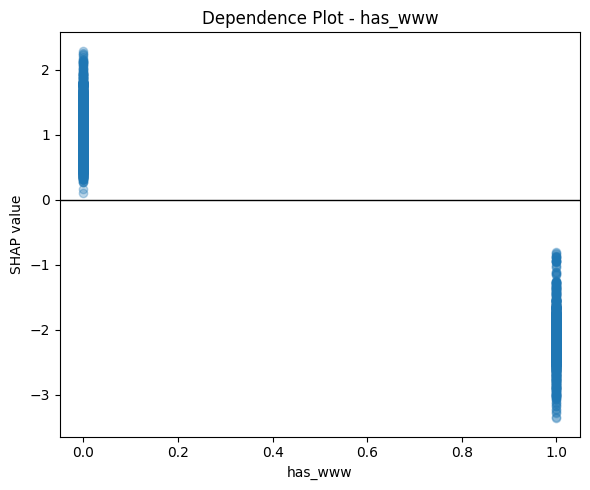

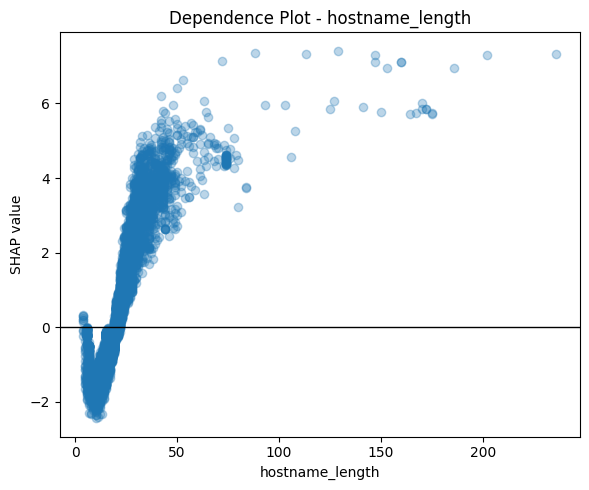

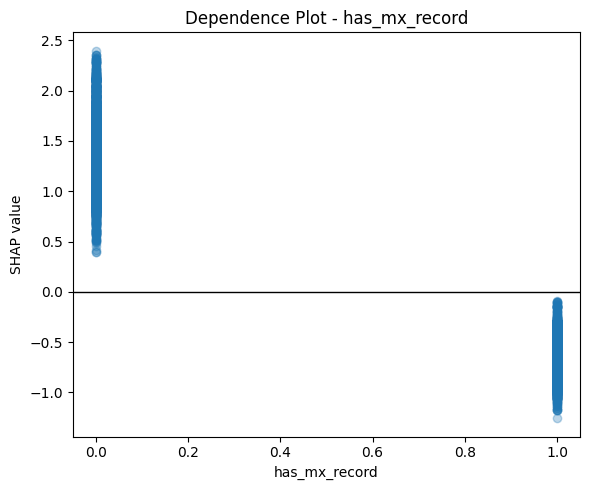

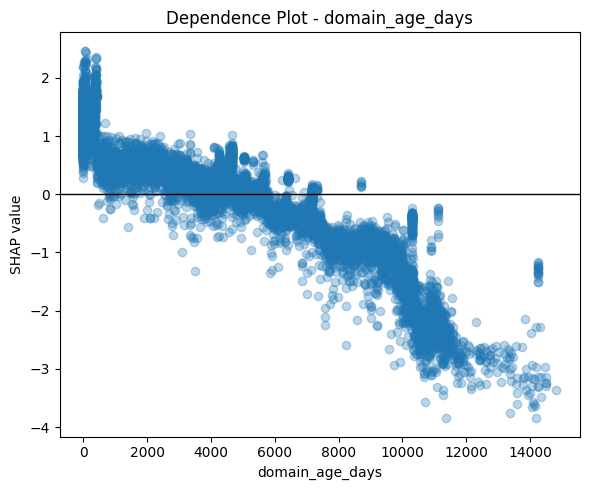

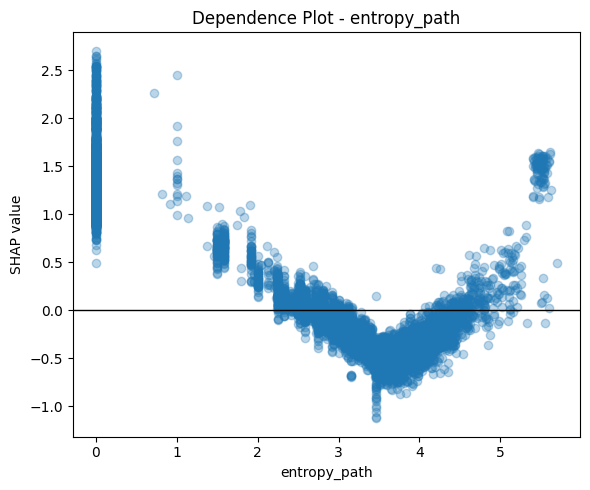

In [29]:
for feat in TOP5:
    idx = list(X.columns).index(feat)

    plt.figure(figsize=(6,5))
    plt.scatter(X[feat], sv[:, idx], alpha=0.3)
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel(feat)
    plt.ylabel("SHAP value")
    plt.title(f"Dependence Plot - {feat}")
    plt.tight_layout()
    plt.show()

C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\2478024000.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("bin").agg(


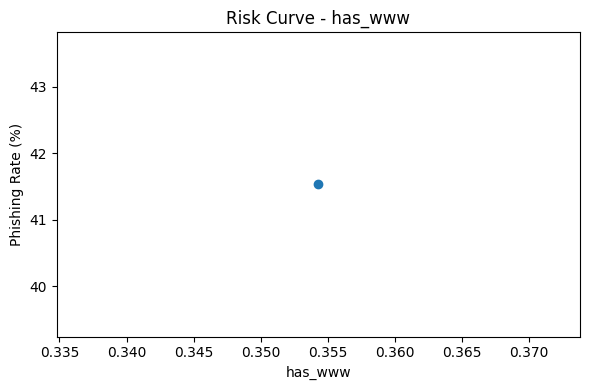

C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\2478024000.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("bin").agg(


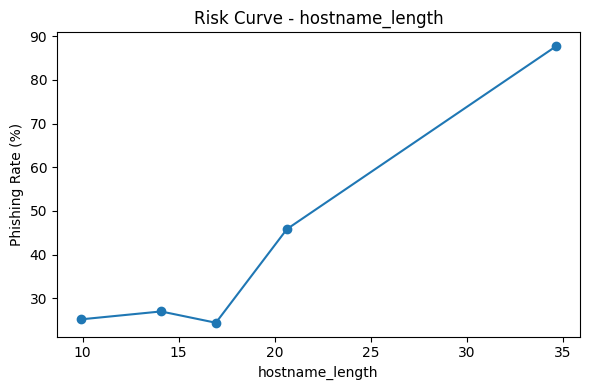

C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\2478024000.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("bin").agg(


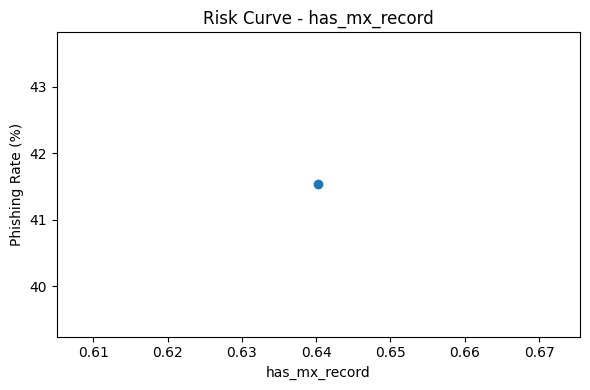

C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\2478024000.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("bin").agg(


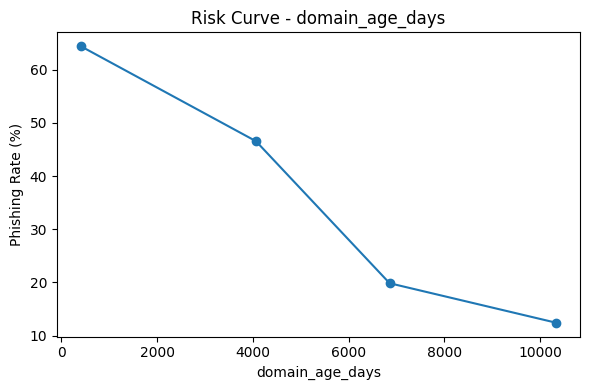

C:\Users\elifo\AppData\Local\Temp\ipykernel_3764\2478024000.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("bin").agg(


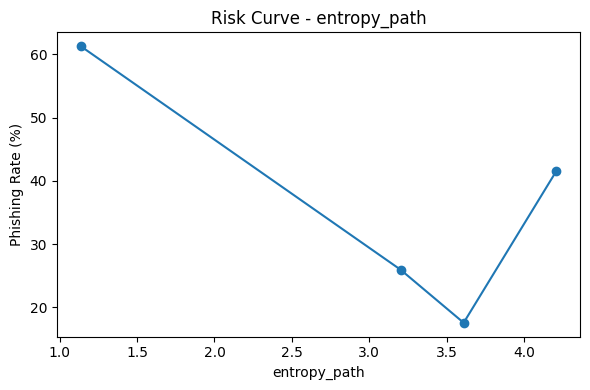

In [30]:
for feat in TOP5:
    df = pd.DataFrame({
        "x": X[feat],
        "y": y
    })

    df["bin"] = pd.qcut(df["x"], 5, duplicates="drop")
    grp = df.groupby("bin").agg(
        phishing_rate=("y", lambda x: 100*x.mean()),
        x_mean=("x", "mean")
    ).reset_index()

    plt.figure(figsize=(6,4))
    plt.plot(grp["x_mean"], grp["phishing_rate"], marker="o")
    plt.xlabel(feat)
    plt.ylabel("Phishing Rate (%)")
    plt.title(f"Risk Curve - {feat}")
    plt.tight_layout()
    plt.show()

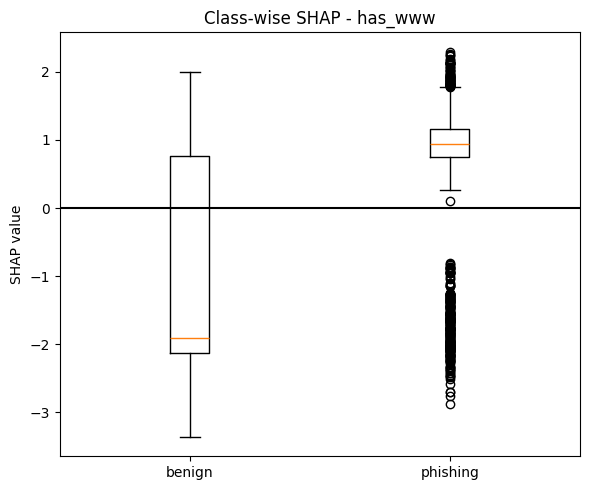

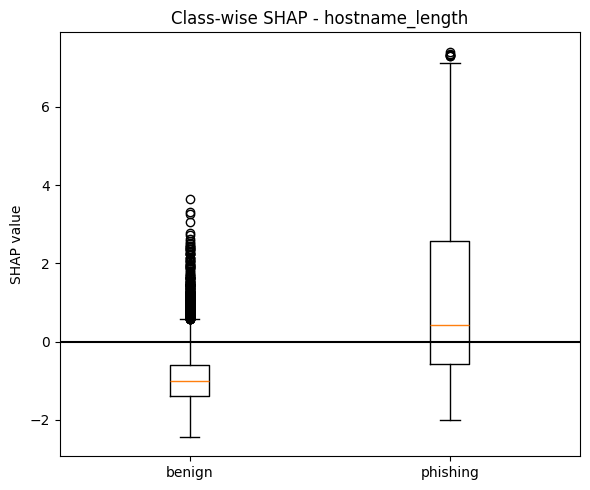

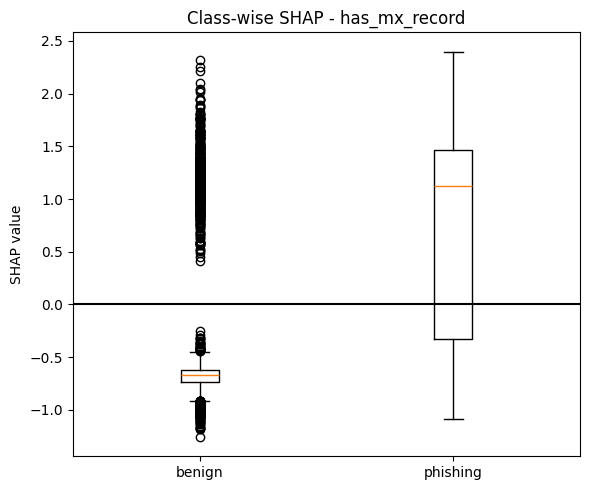

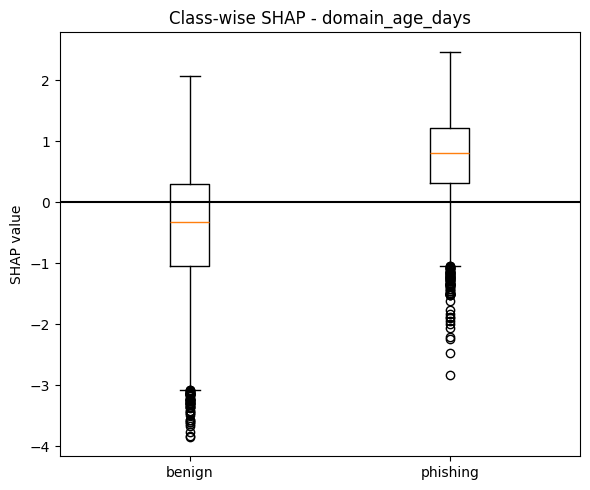

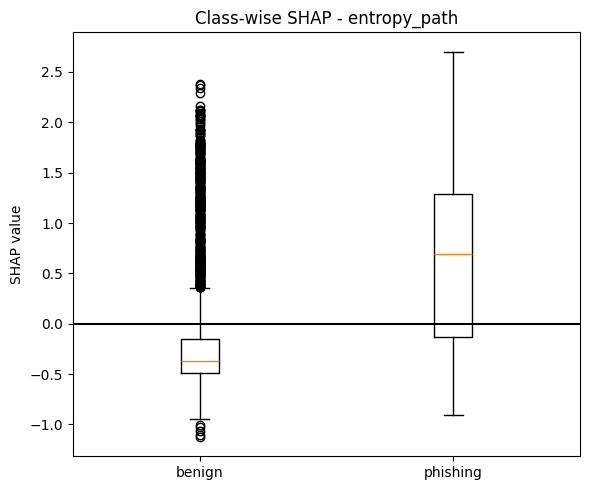

In [31]:
for feat in TOP5:
    idx = list(X.columns).index(feat)

    shap_vals = sv[:, idx]

    x0 = shap_vals[y == 0]
    x1 = shap_vals[y == 1]

    plt.figure(figsize=(6,5))
    plt.boxplot([x0, x1], tick_labels=["benign", "phishing"])
    plt.axhline(0, color="black")
    plt.title(f"Class-wise SHAP - {feat}")
    plt.ylabel("SHAP value")
    plt.tight_layout()
    plt.show()

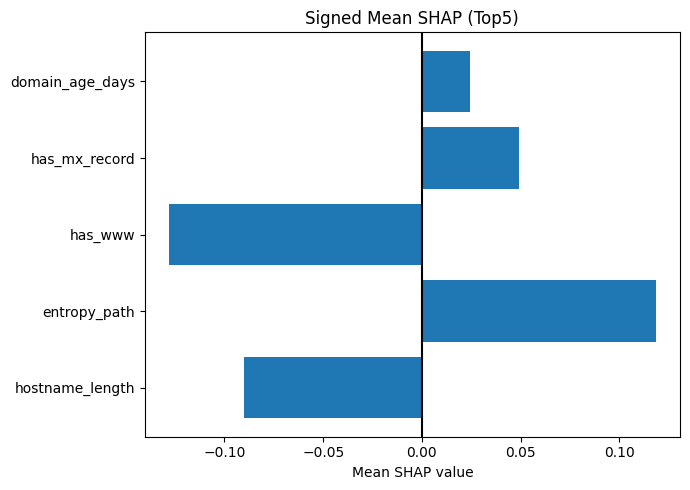

In [32]:
mean_signed = sv.mean(axis=0)
mean_abs = np.abs(sv).mean(axis=0)

df_shap = pd.DataFrame({
    "feature": X.columns,
    "mean_shap": mean_signed,
    "mean_abs_shap": mean_abs
})

df_top = df_shap[df_shap["feature"].isin(TOP5)]

plt.figure(figsize=(7,5))
plt.barh(df_top["feature"], df_top["mean_shap"])
plt.axvline(0, color="black")
plt.title("Signed Mean SHAP (Top5)")
plt.xlabel("Mean SHAP value")
plt.tight_layout()
plt.show()

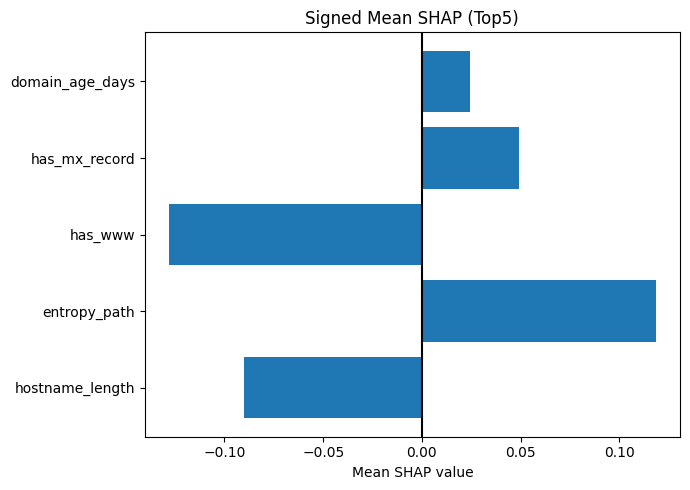

In [33]:
mean_signed = sv.mean(axis=0)
mean_abs = np.abs(sv).mean(axis=0)

df_shap = pd.DataFrame({
    "feature": X.columns,
    "mean_shap": mean_signed,
    "mean_abs_shap": mean_abs
})

df_top = df_shap[df_shap["feature"].isin(TOP5)]

plt.figure(figsize=(7,5))
plt.barh(df_top["feature"], df_top["mean_shap"])
plt.axvline(0, color="black")
plt.title("Signed Mean SHAP (Top5)")
plt.xlabel("Mean SHAP value")
plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path(r"C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale")
BASE_OUT = BASE / "outputs"

# Dataset
DATASET_PATH = BASE / "final_lexical_dns_whois_cleaned.csv"

# Split index dosyaları (senin outputs/_shared altında var)
train_idx_path = BASE_OUT / "_shared" / "split_indices_train.csv"
test_idx_path  = BASE_OUT / "_shared" / "split_indices_test.csv"

# Model pipeline objesi notebook'ta var: pipelines["LightGBM"]
# Eğer yoksa burada yüklemen gerekir (senin notebook'ta zaten var olduğunu varsayıyorum)
pipe = pipelines["LightGBM"]

# Load data
df = pd.read_csv(DATASET_PATH)
feature_cols = [c for c in df.columns if c not in ["url", "label"]]

train_idx = pd.read_csv(train_idx_path).iloc[:,0].astype(int).values
test_idx  = pd.read_csv(test_idx_path).iloc[:,0].astype(int).values

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

X_test_raw = df_test[feature_cols]
y_test = df_test["label"].astype(int).values

print("Test shape:", X_test_raw.shape, "label counts:", pd.Series(y_test).value_counts().to_dict())

Test shape: (115984, 75) label counts: {0: 67815, 1: 48169}


In [35]:
# Predict proba
proba = pipe.predict_proba(X_test_raw)[:, 1]
pred  = (proba >= 0.5).astype(int)

correct_idx = np.where(pred == y_test)[0]
wrong_idx   = np.where(pred != y_test)[0]

print("Correct:", len(correct_idx), "Wrong:", len(wrong_idx))

rng = np.random.RandomState(42)

# 2 doğru: biri phishing biri benign seçelim (daha iyi anlatım)
correct_phish = correct_idx[(y_test[correct_idx] == 1)]
correct_benign= correct_idx[(y_test[correct_idx] == 0)]

pick_correct = []
if len(correct_phish) > 0:
    pick_correct.append(int(rng.choice(correct_phish, 1)[0]))
if len(correct_benign) > 0:
    pick_correct.append(int(rng.choice(correct_benign, 1)[0]))

# 2 yanlış: biri FP biri FN seçelim
wrong_fp = wrong_idx[(pred[wrong_idx] == 1) & (y_test[wrong_idx] == 0)]  # false positive
wrong_fn = wrong_idx[(pred[wrong_idx] == 0) & (y_test[wrong_idx] == 1)]  # false negative

pick_wrong = []
if len(wrong_fp) > 0:
    pick_wrong.append(int(rng.choice(wrong_fp, 1)[0]))
if len(wrong_fn) > 0:
    pick_wrong.append(int(rng.choice(wrong_fn, 1)[0]))

# Eğer sınıflardan biri boşsa, rastgele 2 tane tamamla
while len(pick_correct) < 2:
    pick_correct.append(int(rng.choice(correct_idx, 1)[0]))
while len(pick_wrong) < 2 and len(wrong_idx) > 0:
    pick_wrong.append(int(rng.choice(wrong_idx, 1)[0]))

print("Picked correct:", pick_correct)
print("Picked wrong:", pick_wrong)

samples = []
for i in pick_correct:
    samples.append(("correct", i, int(y_test[i]), int(pred[i]), float(proba[i])))
for i in pick_wrong:
    samples.append(("wrong", i, int(y_test[i]), int(pred[i]), float(proba[i])))

df_samples = pd.DataFrame(samples, columns=["group","test_row","y_true","y_pred","proba_phishing"])
df_samples

C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Correct: 114454 Wrong: 1530
Picked correct: [38798, 1401]
Picked wrong: [65974, 115863]


,group,test_row,y_true,y_pred,proba_phishing
0,correct,38798,1,1,0.999906
1,correct,1401,0,0,0.034076
2,wrong,65974,0,1,0.572751
3,wrong,115863,1,0,0.157935


In [36]:
import shap

out_dir = BASE_OUT / "LightGBM" / "local_final"
(out_dir / "shap_correct").mkdir(parents=True, exist_ok=True)
(out_dir / "shap_wrong").mkdir(parents=True, exist_ok=True)

preprocess = pipe.named_steps["preprocess"]
model = pipe.named_steps["model"]

# preprocess edilmiş test
Xte_proc = preprocess.transform(X_test_raw)

explainer = shap.TreeExplainer(model)

for group, i, y_true, y_pred, p1 in df_samples.values:
    x_i = Xte_proc[i:i+1]
    shap_vals = explainer.shap_values(x_i)

    # binary class -> class=1 al
    if isinstance(shap_vals, list) and len(shap_vals) >= 2:
        sv = shap_vals[1]
        base = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        sv = shap_vals
        base = explainer.expected_value

    exp = shap.Explanation(
        values=sv[0],
        base_values=base,
        data=x_i[0],
        feature_names=feature_cols
    )

    plt.figure()
    shap.plots.waterfall(exp, show=False, max_display=15)
    plt.title(f"LightGBM SHAP waterfall | {group} | row={i} | y={y_true} pred={y_pred} p={p1:.3f}")
    plt.tight_layout()

    fname = f"{group}_{i}_y{y_true}_p{p1:.3f}.png"
    if group == "correct":
        plt.savefig(out_dir / "shap_correct" / fname, dpi=220)
    else:
        plt.savefig(out_dir / "shap_wrong" / fname, dpi=220)
    plt.close()

print("✅ Local SHAP PNG done:", out_dir)

C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


✅ Local SHAP PNG done: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\LightGBM\local_final


In [37]:
from lime.lime_tabular import LimeTabularExplainer

(out_dir / "lime_correct").mkdir(parents=True, exist_ok=True)
(out_dir / "lime_wrong").mkdir(parents=True, exist_ok=True)

# LIME train data needs numpy
X_train_raw = df_train[feature_cols]
Xtr = X_train_raw.values

expl = LimeTabularExplainer(
    training_data=Xtr,
    feature_names=feature_cols,
    class_names=["benign", "phishing"],
    discretize_continuous=True,
    mode="classification"
)

# predict function that accepts numpy
def predict_fn(z):
    z_df = pd.DataFrame(z, columns=feature_cols)
    return pipe.predict_proba(z_df)

for group, i, y_true, y_pred, p1 in df_samples.values:
    x = X_test_raw.iloc[i].values

    exp = expl.explain_instance(
        data_row=x,
        predict_fn=predict_fn,
        num_features=15,
        top_labels=1
    )

    # LIME'in proba ile en ilgili label'ını seç
    label_to_plot = exp.available_labels()[0]

    fig = exp.as_pyplot_figure(label=label_to_plot)
    plt.title(f"LightGBM LIME | {group} | row={i} | y={y_true} pred={y_pred} p={p1:.3f}")
    plt.tight_layout()

    fname = f"{group}_{i}_y{y_true}_p{p1:.3f}.png"
    if group == "correct":
        plt.savefig(out_dir / "lime_correct" / fname, dpi=220)
    else:
        plt.savefig(out_dir / "lime_wrong" / fname, dpi=220)
    plt.close()

print("✅ LIME PNG done:", out_dir)

C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\elifo\anacond3\envs\url_ai\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LIME PNG done: C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\LightGBM\local_final


In [38]:
df_samples.to_csv(out_dir / "local_samples.csv", index=False, encoding="utf-8")
print("✅ Saved local_samples.csv ->", out_dir / "local_samples.csv")

✅ Saved local_samples.csv -> C:\Users\elifo\Bitirme_Projesi_Dataset_Olusturma\Makale\outputs\LightGBM\local_final\local_samples.csv
